Going to use the -short files now to hopefully get a slice and plot intensity. Want to pick the clearest one.

Edit: will stick to the regular files for a bit longer.

In [3]:
import sunpy.map
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np

files = sorted(glob.glob('../data/20260820T154500/solo_L2_eui-hrieuv174-image_20260820T16*.fits'))

maps = [sunpy.map.Map(f) for f in files]
map_times = pd.to_datetime([m.date.iso for m in maps])

target = pd.Timestamp("2026-08-20 16:29:46")
closest_idx = np.abs(map_times - target).argmin()

m = maps[closest_idx]
print(m.date.iso)

2026-08-20 16:29:56.285


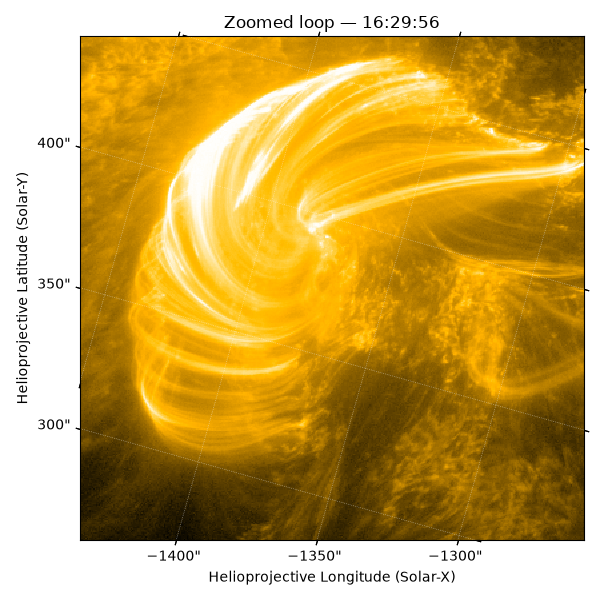

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord

zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left = SkyCoord(-1370*u.arcsec - zoom_width/2, 375*u.arcsec - zoom_height/2,
                        frame=m.coordinate_frame)
top_right = SkyCoord(-1370*u.arcsec + zoom_width/2, 375*u.arcsec + zoom_height/2,
                      frame=m.coordinate_frame)

zoomed_map = m.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)
zoomed_map.plot(axes=ax)
ax.set_title(f'Zoomed loop — {m.date.iso[11:19]}')
plt.tight_layout()
plt.savefig('../figures/eui_loop_zoom.png')
plt.show()

In [1]:
%matplotlib widget

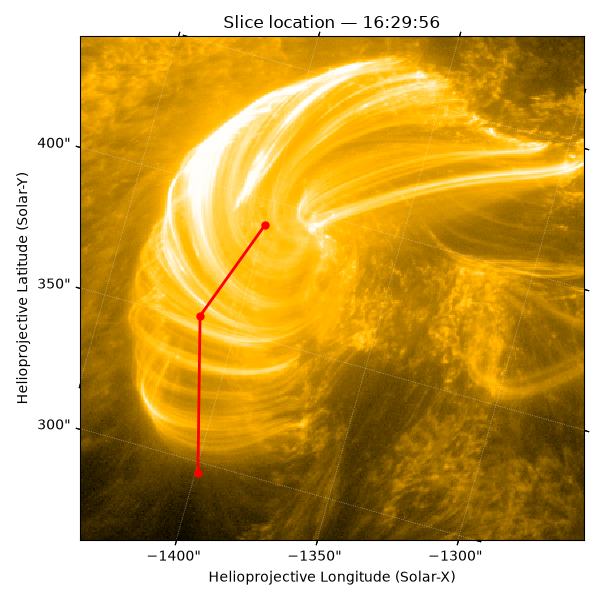

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord

#start and end points of the first slice
start = SkyCoord(
    -1399 * u.arcsec,
    296 * u.arcsec,
    frame=zoomed_map.coordinate_frame
)

end = SkyCoord(
    -1414 * u.arcsec,
    352 * u.arcsec,
    frame=zoomed_map.coordinate_frame
)

#new endpoint for the second segment
end2 = SkyCoord(
    -1400 * u.arcsec,
    391 * u.arcsec,
    frame=zoomed_map.coordinate_frame
)

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)

zoomed_map.plot(axes=ax)

#first slice segment
ax.plot_coord(
    SkyCoord(
        [start.Tx, end.Tx],
        [start.Ty, end.Ty],
        frame=zoomed_map.coordinate_frame
    ),
    color="red",
    linewidth=2
)

#second slice segment
ax.plot_coord(
    SkyCoord(
        [end.Tx, end2.Tx],
        [end.Ty, end2.Ty],
        frame=zoomed_map.coordinate_frame
    ),
    color="red",
    linewidth=2
)

ax.plot_coord(
    SkyCoord(
        [start.Tx, end.Tx, end2.Tx],
        [start.Ty, end.Ty, end2.Ty],
        frame=zoomed_map.coordinate_frame
    ),
    marker="o",
    linestyle="none",
    color="red",
    markersize=5
)

ax.set_title(
    f"Slice location — {m.date.iso[11:19]}"
)

plt.tight_layout()

plt.savefig(
    "../figures/eui_slice_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Start pixel: 88.04194831974266 49.92787100956684
Middle pixel: 89.61954232255471 167.7511656854199
End pixel: 138.53768004556196 236.30913247311292
Data unit: DN / s
BUNIT: DN/s


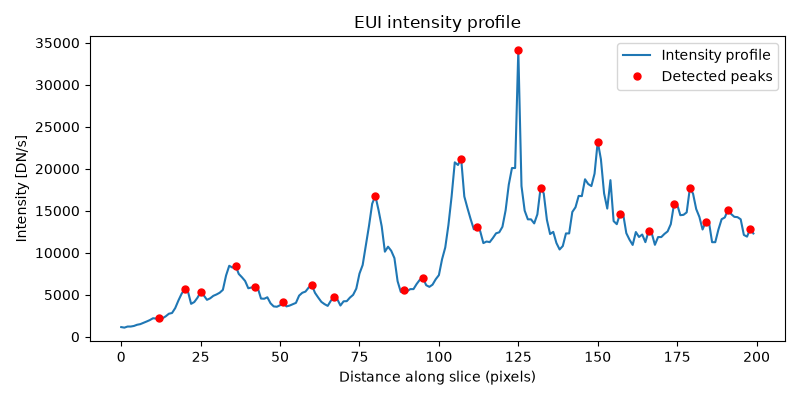

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#convert all three world coordinates to pixels


start_pixel = zoomed_map.world_to_pixel(start)
end_pixel = zoomed_map.world_to_pixel(end)
end2_pixel = zoomed_map.world_to_pixel(end2)

x1, y1 = start_pixel[0].value, start_pixel[1].value
x2, y2 = end_pixel[0].value, end_pixel[1].value
x3, y3 = end2_pixel[0].value, end2_pixel[1].value


#create pixels along the first segment

n_points_1 = int(np.hypot(x2 - x1, y2 - y1))

x_pixels_1 = np.linspace(x1, x2, n_points_1)
y_pixels_1 = np.linspace(y1, y2, n_points_1)


#create pixels along the second segment


n_points_2 = int(np.hypot(x3 - x2, y3 - y2))

x_pixels_2 = np.linspace(x2, x3, n_points_2)
y_pixels_2 = np.linspace(y2, y3, n_points_2)

#combine both segments
#remove the duplicate middle point

x_pixels = np.concatenate([
    x_pixels_1,
    x_pixels_2[1:]
])

y_pixels = np.concatenate([
    y_pixels_1,
    y_pixels_2[1:]
])


x_pixels = np.round(x_pixels).astype(int)
y_pixels = np.round(y_pixels).astype(int)


#make sure to stay inside the image


valid = (
    (x_pixels >= 0) &
    (x_pixels < zoomed_map.data.shape[1]) &
    (y_pixels >= 0) &
    (y_pixels < zoomed_map.data.shape[0])
)

x_pixels = x_pixels[valid]
y_pixels = y_pixels[valid]



#extract intensity along the complete path

intensity = zoomed_map.data[y_pixels, x_pixels]

print("Data unit:", m.unit)
print("BUNIT:", m.meta.get("BUNIT"))


#distance along the complete slice
distance = np.arange(len(intensity))


#detect peaks
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    intensity,
    prominence=np.std(intensity) * 0.005,
    distance=5
)



plt.figure(figsize=(8, 4))

plt.plot(
    distance,
    intensity,
    label="Intensity profile"
)

plt.plot(
    distance[peaks],
    intensity[peaks],
    "ro",
    markersize=5,
    label="Detected peaks"
)

plt.xlabel("Distance along slice (pixels)")
plt.ylabel("Intensity [DN/s]")
plt.title("EUI intensity profile")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/eui_intensity_profile_peaks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of peaks: 23
Peak 1: lon = -1400.63 arcsec, lat = 301.71 arcsec
Peak 2: lon = -1401.70 arcsec, lat = 305.50 arcsec
Peak 3: lon = -1402.37 arcsec, lat = 307.87 arcsec
Peak 4: lon = -1403.37 arcsec, lat = 313.21 arcsec
Peak 5: lon = -1404.30 arcsec, lat = 316.52 arcsec
Peak 6: lon = -1405.51 arcsec, lat = 320.78 arcsec
Peak 7: lon = -1406.71 arcsec, lat = 325.05 arcsec
Peak 8: lon = -1407.64 arcsec, lat = 328.36 arcsec
Peak 9: lon = -1409.38 arcsec, lat = 334.52 arcsec
Peak 10: lon = -1410.58 arcsec, lat = 338.78 arcsec
Peak 11: lon = -1411.39 arcsec, lat = 341.62 arcsec
Peak 12: lon = -1413.12 arcsec, lat = 347.77 arcsec
Peak 13: lon = -1413.32 arcsec, lat = 350.27 arcsec
Peak 14: lon = -1412.42 arcsec, lat = 356.15 arcsec
Peak 15: lon = -1411.33 arcsec, lat = 359.53 arcsec
Peak 16: lon = -1408.13 arcsec, lat = 368.10 arcsec
Peak 17: lon = -1407.03 arcsec, lat = 371.48 arcsec
Peak 18: lon = -1405.60 arcsec, lat = 375.46 arcsec
Peak 19: lon = -1404.17 arcsec, lat = 379.44 arcsec
P

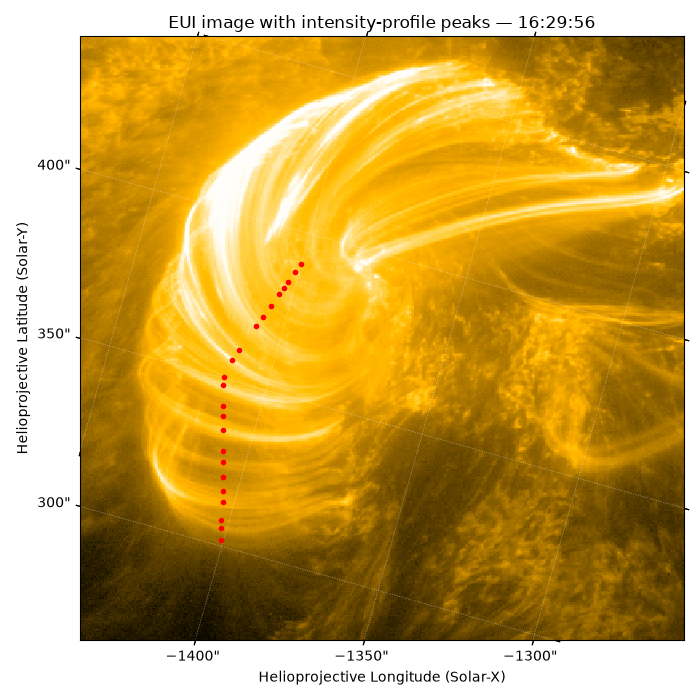

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import astropy.units as u
from astropy.coordinates import SkyCoord


peaks, properties = find_peaks(
    intensity,
    prominence=np.std(intensity) * 0.005,
    distance=5
)

print("Number of peaks:", len(peaks))


#get the pixel coordinates of each peak

peak_x_pixels = x_pixels[peaks]
peak_y_pixels = y_pixels[peaks]


peak_coords = zoomed_map.pixel_to_world(
    peak_x_pixels * u.pix,
    peak_y_pixels * u.pix
)


for i, coord in enumerate(peak_coords):
    print(
        f"Peak {i+1}: "
        f"lon = {coord.Tx.to(u.arcsec):.2f}, "
        f"lat = {coord.Ty.to(u.arcsec):.2f}"
    )



fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)

zoomed_map.plot(axes=ax)

ax.plot_coord(
    peak_coords,
    marker="o",
    linestyle="none",
    markersize=3,
    color="red"
)

ax.set_title(
    f"EUI image with intensity-profile peaks — {m.date.iso[11:19]}"
)

plt.tight_layout()

plt.savefig(
    "../figures/eui_slice_peaks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of peaks: 10


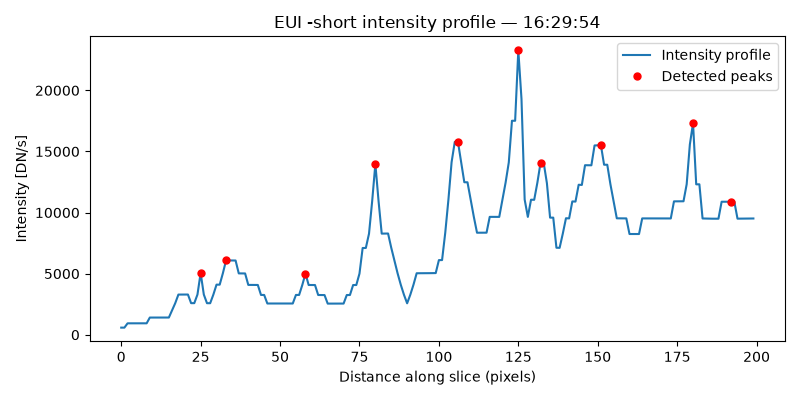

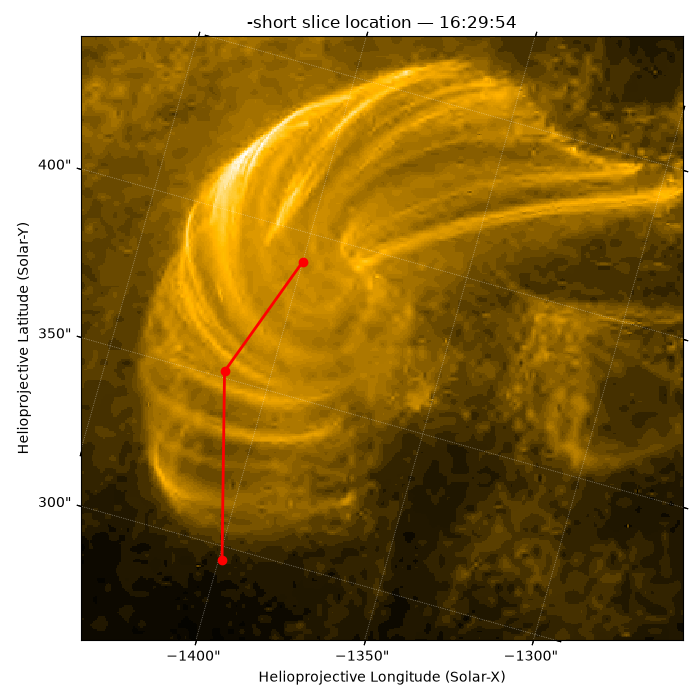

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
import astropy.units as u
from astropy.coordinates import SkyCoord
from scipy.signal import find_peaks

short_file = (
    "../data/20260820T154500/"
    "solo_L2_eui-hrieuv174-image-short_20260820T162954285_V00.fits"
)

m_short = sunpy.map.Map(short_file)


zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left_short = SkyCoord(
    -1370 * u.arcsec - zoom_width / 2,
    375 * u.arcsec - zoom_height / 2,
    frame=m_short.coordinate_frame
)

top_right_short = SkyCoord(
    -1370 * u.arcsec + zoom_width / 2,
    375 * u.arcsec + zoom_height / 2,
    frame=m_short.coordinate_frame
)

zoomed_map_short = m_short.submap(
    bottom_left_short,
    top_right=top_right_short
)

start_short = SkyCoord(
    -1399 * u.arcsec,
    296 * u.arcsec,
    frame=zoomed_map_short.coordinate_frame
)

end_short = SkyCoord(
    -1414 * u.arcsec,
    352 * u.arcsec,
    frame=zoomed_map_short.coordinate_frame
)

end2_short = SkyCoord(
    -1400 * u.arcsec,
    391 * u.arcsec,
    frame=zoomed_map_short.coordinate_frame
)

start_pixel = zoomed_map_short.world_to_pixel(start_short)
end_pixel = zoomed_map_short.world_to_pixel(end_short)
end2_pixel = zoomed_map_short.world_to_pixel(end2_short)

x1, y1 = start_pixel[0].value, start_pixel[1].value
x2, y2 = end_pixel[0].value, end_pixel[1].value
x3, y3 = end2_pixel[0].value, end2_pixel[1].value

n_points_1 = int(np.hypot(x2 - x1, y2 - y1))

x_pixels_1 = np.linspace(x1, x2, n_points_1)
y_pixels_1 = np.linspace(y1, y2, n_points_1)


n_points_2 = int(np.hypot(x3 - x2, y3 - y2))

x_pixels_2 = np.linspace(x2, x3, n_points_2)
y_pixels_2 = np.linspace(y2, y3, n_points_2)



x_pixels = np.concatenate([
    x_pixels_1,
    x_pixels_2[1:]
])

y_pixels = np.concatenate([
    y_pixels_1,
    y_pixels_2[1:]
])

x_pixels = np.round(x_pixels).astype(int)
y_pixels = np.round(y_pixels).astype(int)

valid = (
    (x_pixels >= 0) &
    (x_pixels < zoomed_map_short.data.shape[1]) &
    (y_pixels >= 0) &
    (y_pixels < zoomed_map_short.data.shape[0])
)

x_pixels = x_pixels[valid]
y_pixels = y_pixels[valid]


intensity_short = zoomed_map_short.data[
    y_pixels,
    x_pixels
]

distance_short = np.arange(len(intensity_short))


peaks_short, properties_short = find_peaks(
    intensity_short,
    prominence=np.std(intensity_short) * 0.005,
    distance=5
)

print("Number of peaks:", len(peaks_short))



plt.figure(figsize=(8, 4))

plt.plot(
    distance_short,
    intensity_short,
    label="Intensity profile"
)

plt.plot(
    distance_short[peaks_short],
    intensity_short[peaks_short],
    "ro",
    markersize=5,
    label="Detected peaks"
)

plt.xlabel("Distance along slice (pixels)")
plt.ylabel("Intensity [DN/s]")

plt.title(
    f"EUI -short intensity profile — {m_short.date.iso[11:19]}"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "../figures/eui_short_intensity_profile_peaks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map_short.wcs
)

zoomed_map_short.plot(axes=ax)

ax.plot_coord(
    SkyCoord(
        [start_short.Tx, end_short.Tx],
        [start_short.Ty, end_short.Ty],
        frame=zoomed_map_short.coordinate_frame
    ),
    color="red",
    linewidth=2
)

ax.plot_coord(
    SkyCoord(
        [end_short.Tx, end2_short.Tx],
        [end_short.Ty, end2_short.Ty],
        frame=zoomed_map_short.coordinate_frame
    ),
    color="red",
    linewidth=2
)


ax.plot_coord(
    SkyCoord(
        [start_short.Tx, end_short.Tx, end2_short.Tx],
        [start_short.Ty, end_short.Ty, end2_short.Ty],
        frame=zoomed_map_short.coordinate_frame
    ),
    marker="o",
    linestyle="none",
    color="red",
    markersize=6
)

ax.set_title(
    f"-short slice location — {m_short.date.iso[11:19]}"
)

plt.tight_layout()

plt.savefig(
    "../figures/eui_short_slice_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of peaks: 10
Peak 1: lon = -1402.32 arcsec, lat = 307.82 arcsec
Peak 2: lon = -1403.52 arcsec, lat = 312.08 arcsec
Peak 3: lon = -1406.39 arcsec, lat = 324.05 arcsec
Peak 4: lon = -1409.33 arcsec, lat = 334.47 arcsec
Peak 5: lon = -1412.93 arcsec, lat = 347.26 arcsec
Peak 6: lon = -1412.37 arcsec, lat = 356.11 arcsec
Peak 7: lon = -1411.27 arcsec, lat = 359.48 arcsec
Peak 8: lon = -1408.20 arcsec, lat = 368.53 arcsec
Peak 9: lon = -1403.36 arcsec, lat = 382.16 arcsec
Peak 10: lon = -1401.38 arcsec, lat = 387.84 arcsec


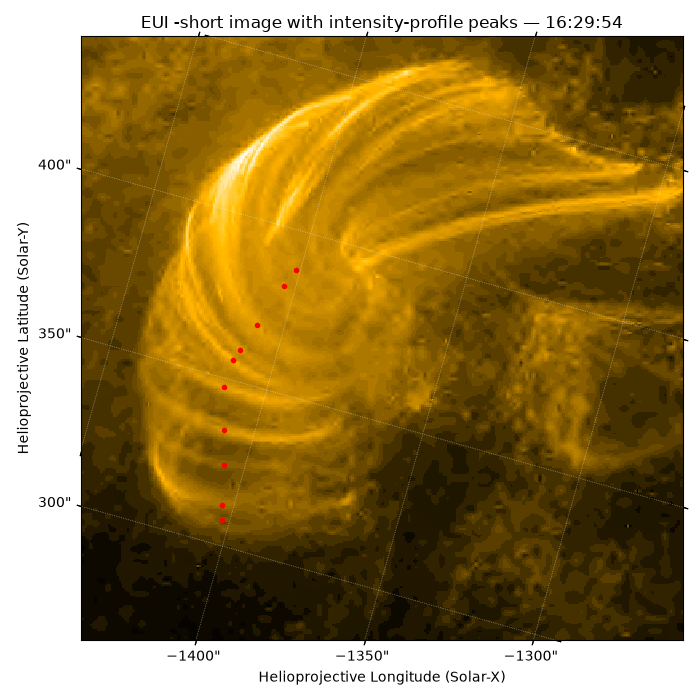

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import astropy.units as u
from astropy.coordinates import SkyCoord

#find all peaks in the -short intensity profile

peaks_short, properties_short = find_peaks(
    intensity_short,
    prominence=np.std(intensity_short) * 0.005,
    distance=5
)


peak_x_pixels_short = x_pixels[peaks_short]
peak_y_pixels_short = y_pixels[peaks_short]


peak_coords_short = zoomed_map_short.pixel_to_world(
    peak_x_pixels_short * u.pix,
    peak_y_pixels_short * u.pix
)


for i, coord in enumerate(peak_coords_short):
    print(
        f"Peak {i+1}: "
        f"lon = {coord.Tx.to(u.arcsec):.2f}, "
        f"lat = {coord.Ty.to(u.arcsec):.2f}"
    )

fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map_short.wcs
)

zoomed_map_short.plot(axes=ax)

ax.plot_coord(
    peak_coords_short,
    marker="o",
    linestyle="none",
    markersize=3,
    color="red"
)

ax.set_title(
    f"EUI -short image with intensity-profile peaks — "
    f"{m_short.date.iso[11:19]}"
)

plt.tight_layout()

plt.savefig(
    "../figures/eui_short_slice_peaks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()